In [154]:
import numpy as np
from random import uniform
import matplotlib.pyplot as plt
import quantecon as qe


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
def p(x, coeffs):

    powers = np.ones_like(coeffs)
    powers[1:] = x
    X_powers = np.cumprod(powers)
    X_powers = X_powers * coeffs

    return X_powers.sum()


print(p(2,[2,3,4]))

24


In [61]:
class DiscreteRV:

    def __init__(self, q):

        self.q = q
        

        
    def draw(self,k = 1):

        draws = np.random.uniform(size=k)
        I = np.cumsum(self.q)
        index = np.searchsorted(I,draws)
        
        return index

d = DiscreteRV([0.25,0.75])
print(d.draw(4))

[1 1 1 1]


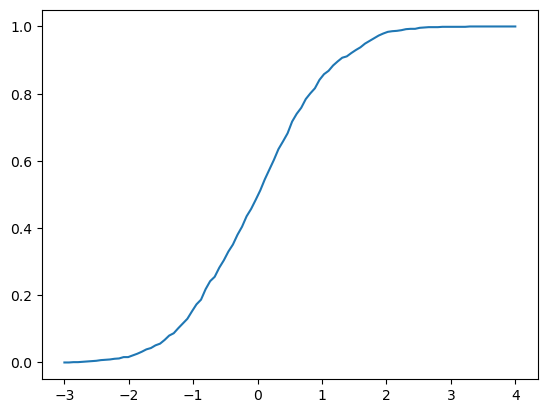

0.7


In [135]:
class ECDF:

    def __init__(self,observations):

        self.observations = observations
    
    def __call__(self, x):

        sorted_obs = np.sort(self.observations)
                
        return (np.searchsorted(sorted_obs, x)) / (len(self.observations))
    
    def plot(self, a, b):
        x = np.linspace(a, b, num=100)
        f = np.vectorize(self.__call__)
        plt.plot(x,f(x))
        plt.show()
        


        

samples = np.random.randn(1000)
F = ECDF(samples)
F.plot(-3,4)
print(F(0.5))
        

In [168]:
np.random.seed(123)
x = np.random.randn(4, 4)
y = np.random.randn(4)

A = np.empty_like(x)
for i in range(4):
    for j in range(4):
        A[i][j] = x[i][j] / y[j]

D = x / y
print(np.array_equal(A,D))




True


In [174]:
np.random.seed(123)
z = np.random.randn(1000, 100, 100)
q = np.random.randn(100)

B = np.empty_like(z)
with qe.Timer("Broadcasting operation"):
    for i in range(1000):
        for j in range(100):
            for k in range(100):
                B[i][j][k] = z[i][j][k] / q[k]

with qe.Timer("Broadcasting operation"):
    C = z / q

print(np.array_equal(C,B))

Broadcasting operation: 4.6019 seconds elapsed
Broadcasting operation: 0.0140 seconds elapsed
True
